# Findgoal Environment

> A multigrid environment, where the agent has to find a goal in a maze. The agent receives a reward of 1 when it reaches the goal, and 0 otherwise. The episode ends when the agent reaches the goal or after a maximum number of steps.

In [ ]:
#| default_exp envs.findgoal

In [ ]:
#| hide
from nbdev.showdoc import *

In [ ]:
#| export
from __future__ import annotations

import math
from collections import defaultdict
from itertools import repeat


from fastcore.utils import patch
import numpy as np
from numpy.typing import NDArray as ndarray

from typing import Any, Callable, Iterable, Literal, SupportsFloat

import gymnasium as gym
from gymnasium import spaces

from multigrid.envs.base import MultiGridEnv
from multigrid.envs.roomgrid import RoomGrid
from multigrid.utils.random import RandomMixin
from multigrid.core import Grid
from multigrid.core.constants import Direction, Color, Type, TILE_PIXELS
from multigrid.core.world_object import Goal, Marker, Wall, WorldObj
from multigrid.core.agent import Agent, AgentState, NavigationAgent
from multigrid.utils.obs import gen_obs_grid_encoding, gen_obs_grid_image
from multigrid.core.actions import Action, NavigationAction




In [ ]:
#| export
AgentID = int
ObsType = dict[str, Any]


In [ ]:
#| export
class FindGoalEnv(MultiGridEnv):
    """
    Multi-room environment where agents must find and reach the green goal.
    Rooms are separated by walls with open gaps (no doors).
    Random wall obstacles are scattered inside rooms as visual/navigation clutter.
    """

    def __init__(
        self,
        size: int = 15,
        width: int = 30,
        height: int = 20,
        num_obstacles: int = 25,
        n_clutter: int = 10,
        randomize_goal: bool = True,
        max_steps: int = 250,
        joint_reward: bool = False,
        success_termination_mode: str = 'all',
        allow_agent_overlap: bool = False,
        see_through_walls: bool = True,
        min_goal_spawn_distance: int = 5,
        **kwargs
    ):
        self.num_obstacles = num_obstacles
        self.randomize_goal = randomize_goal
        self.n_clutter = n_clutter
        self.min_goal_spawn_distance = min_goal_spawn_distance
        self._goal_rng = np.random.default_rng()

        super().__init__(
            mission_space="get to the green goal square",
            grid_size= size,
            width=width,
            height=height,
            max_steps=max_steps,
            joint_reward=joint_reward,
            success_termination_mode=success_termination_mode,
            allow_agent_overlap=allow_agent_overlap,
            see_through_walls=see_through_walls,
            **kwargs,
        )

        # reinstantiate the agents to be NavigationAgents (different action space)
        agent_view_size = self.agents[0].view_size if isinstance(self.agents, Iterable) else 7
        self.agent_states = AgentState(self.num_agents) # joint agent state (vectorized)
        self.agents: list[NavigationAgent] = []
        for i in range(self.num_agents):
            agent = NavigationAgent(
                index=i,
                mission_space=self.mission_space,
                view_size=agent_view_size,
                see_through_walls=see_through_walls,
            )
            agent.state = self.agent_states[i]
            self.agents.append(agent)

        # Action enumeration for this environment
        self.actions = NavigationAction

    def _gen_grid(self: MultiGridEnv, width, height):
        # 1. Create empty grid with surrounding walls
        self.grid = Grid(width, height)
        self.grid.wall_rect(0, 0, width, height)

        # 2. Scatter rectangular wall obstacles
        obstacles_placed = 0
        max_attempts = 1000

        while obstacles_placed < self.num_obstacles and max_attempts > 0:
            max_attempts -= 1
            obs_w = self.np_random.integers(2, 5)
            obs_h = self.np_random.integers(1, 3)
            ox = self.np_random.integers(1, width  - obs_w - 1)
            oy = self.np_random.integers(1, height - obs_h - 1)

            conflict = any(
                self.grid.get(ox + dx, oy + dy) is not None
                for dx in range(obs_w)
                for dy in range(obs_h)
            )
            if conflict:
                continue

            for dx in range(obs_w):
                for dy in range(obs_h):
                    self.grid.set(ox + dx, oy + dy, Wall(color=Color.grey))
            obstacles_placed += 1

        # 3. Place goal
        if self.randomize_goal:
            goal_pos = self.place_obj(
                Goal(),
                top=(1, 1),
                size=(width - 2, height - 2),
                max_tries=100,
            )
        else:
            goal_pos = np.asarray([width - 2, height - 2])
            self.put_obj(Goal(), width - 2, height - 2)
        self.goal_pos = goal_pos

        # 4. Extra single-cell clutter
        for _ in range(self.n_clutter):
            self.place_obj(Wall(), max_tries=100)

        # 5. Place agents
        def reject_spawn_fn(env, pos):
            """Reject positions too close to goal (where goal might be visible)"""
            print("Rejecting spawn positions too close to goal")
            print(f"Goal pos: {goal_pos}, Candidate pos: {pos}")
            # dist = abs(pos[0] - goal_pos[0]) + abs(pos[1] - goal_pos[1])
            # another way of doing the same as above is through manhattan distance: dist = np.sum(np.abs(np.array(pos) - goal_pos))
            dist = np.linalg.norm(np.array(pos) - goal_pos, ord=1)
            return dist < self.min_goal_spawn_distance
        
        for agent in self.agents:
            self.place_agent(agent, top=(1, 1), size=(width - 2, height - 2), reject_fn= reject_spawn_fn)

        return goal_pos

    def reset(self, seed=None, **kwargs):
        self._last_obs = {}   # clear frozen obs cache
        return super().reset(seed=seed, **kwargs)


In [ ]:
#| export
@patch
def place_agent(
    self: FindGoalEnv,
    agent: NavigationAgent,
    top=None,
    size=None,
    rand_dir=True,
    max_tries=math.inf,
    reject_fn: Callable[[FindGoalEnv, tuple[int, int]], bool] | None = None) -> tuple[int, int]:
    """
    Set agent starting point at an empty position in the grid.
    """
    agent.state.pos = (-1, -1)
    pos = self.place_obj(None, top, size, max_tries=max_tries, reject_fn=reject_fn)
    agent.state.pos = pos

    if rand_dir:
        agent.state.dir = self._rand_int(0, 4)

    return pos

In [ ]:
#| export
@patch
def place_obj(
    self: FindGoalEnv,
    obj: WorldObj | None,
    top: tuple[int, int] = None,
    size: tuple[int, int] = None,
    reject_fn: Callable[[FindGoalEnv, tuple[int, int]], bool] | None = None,
    max_tries=math.inf) -> tuple[int, int]:
    """
    Place an object at an empty position in the grid.

    Parameters
    ----------
    obj: WorldObj
        Object to place in the grid
    top: tuple[int, int]
        Top-left position of the rectangular area where to place the object
    size: tuple[int, int]
        Width and height of the rectangular area where to place the object
    reject_fn: Callable[FindGoalEnv, tuple[int, int]] -> bool
        Function to filter out potential positions
    max_tries: int
        Maximum number of attempts to place the object
    """
    if top is None:
        top = (0, 0)
    else:
        top = (max(top[0], 0), max(top[1], 0))

    if size is None:
        size = (self.grid.width, self.grid.height)

    num_tries = 0

    while True:
        # This is to handle with rare cases where rejection sampling
        # gets stuck in an infinite loop
        if num_tries > max_tries:
            raise RecursionError("rejection sampling failed in place_obj")

        num_tries += 1

        
        if obj is not None and obj.type == Type.goal:
            rng = self._goal_rng
        else:
            rng = self.np_random
            
        pos = (
            rng.integers(top[0], min(top[0] + size[0], self.grid.width)),
            rng.integers(top[1], min(top[1] + size[1], self.grid.height)),
        )

        # Don't place the object on top of another object
        if self.grid.get(*pos) is not None:
            continue

        # Don't place the object where agents are
        if np.bitwise_and.reduce(self.agent_states.pos == pos, axis=1).any():
            continue

        # Check if there is a filtering criterion
        if reject_fn and reject_fn(self, pos):
            continue

        break

    self.grid.set(pos[0], pos[1], obj)

    if obj is not None:
        obj.init_pos = pos
        obj.cur_pos = pos

    return pos



In [ ]:
#| export
@patch
def step(
    self: FindGoalEnv,
    actions: dict[AgentID, NavigationAction]) -> tuple[
        dict[AgentID, ObsType],
        dict[AgentID, SupportsFloat],
        dict[AgentID, bool],
        dict[AgentID, bool],
        dict[AgentID, dict[str, Any]]]:
    """
    Run one timestep of the environment’s dynamics
    using the provided agent actions.

    Parameters
    ----------
    actions : dict[AgentID, NavigationAction]
        Navigation action for each agent acting at this timestep

    Returns
    -------
    observations : dict[AgentID, ObsType]
        Observation for each agent
    rewards : dict[AgentID, SupportsFloat]
        Reward for each agent
    terminations : dict[AgentID, bool]
        Whether the episode has been terminated for each agent (success or failure)
    truncations : dict[AgentID, bool]
        Whether the episode has been truncated for each agent (max steps reached)
    infos : dict[AgentID, dict[str, Any]]
        Additional information for each agent
    """
    self.step_count += 1
    rewards = self.handle_actions(actions)

    # Generate outputs
    observations = self.gen_obs()
    terminations = dict(enumerate(self.agent_states.terminated))
    truncated = self.step_count >= self.max_steps
    truncations = dict(enumerate(repeat(truncated, self.num_agents)))

    # Rendering
    if self.render_mode == 'human':
        self.render()

    return observations, rewards, terminations, truncations, {'action': None}#defaultdict(dict)

In [ ]:
#| export
@patch
def handle_actions(
    self: FindGoalEnv, actions: dict[AgentID, NavigationAction]) -> dict[AgentID, SupportsFloat]:
    """
    Handle actions taken by agents.

    Parameters
    ----------
    actions : dict[AgentID, NavigationAction]
        Navigation action for each agent acting at this timestep

    Returns
    -------
    rewards : dict[AgentID, SupportsFloat]
        Reward for each agent
    """
    rewards = {agent_index: 0 for agent_index in range(self.num_agents)}

    # Randomize agent action order
    if self.num_agents == 1:
        order = (0,)
    else:
        order = self.np_random.random(size=self.num_agents).argsort()

    # Update agent states, grid states, and reward from actions
    for i in order:
        if i not in actions:
            continue

        agent, action = self.agents[i], actions[i]

        if agent.state.terminated:
            continue

        # Rotate left
        if action == NavigationAction.left:
            agent.state.dir = (agent.state.dir - 1) % 4

        # Rotate right
        elif action == NavigationAction.right:
            agent.state.dir = (agent.state.dir + 1) % 4

        # Move forward
        elif action == NavigationAction.forward:
            fwd_pos = agent.front_pos
            fwd_obj = self.grid.get(*fwd_pos)

            if fwd_obj is None or fwd_obj.can_overlap():
                if not self.allow_agent_overlap:
                    # agent_present = np.bitwise_and.reduce(
                    #     self.agent_states.pos == fwd_pos, axis=1).any()

                    # ── Fix: exclude self AND terminated agents ────────────
                    # Terminated agents are at (-1,-1) but better to be explicit
                    other_active_positions = [
                        self.agents[j].state.pos
                        for j in range(self.num_agents)
                        if j != i                              # not self
                        and not self.agents[j].state.terminated  # not terminated
                    ]

                    agent_present = any(
                        np.array_equal(pos, fwd_pos)
                        for pos in other_active_positions
                    )
                    
                    if agent_present:
                        continue

                agent.state.pos = fwd_pos
                if fwd_obj is not None:
                    if fwd_obj.type == Type.goal:
                        self.on_success(agent, rewards, {})
                    if fwd_obj.type == Type.lava:
                        self.on_failure(agent, rewards, {})

        # Done action (not used by default)
        elif action == NavigationAction.done:
            pass

        else:
            raise ValueError(f"Unknown action: {action}")

    return rewards



In [ ]:
#| export
@patch
def on_success(
    self: FindGoalEnv,
    agent: Agent,
    rewards: dict[AgentID, SupportsFloat],
    terminations: dict[AgentID, bool]):

    if self.success_termination_mode == 'any':
        self.agent_states.terminated = True
        for i in range(self.num_agents):
            terminations[i] = True
    else:
        agent.state.terminated = True
        terminations[agent.index] = True

        # Cache terminal obs using EXACT same call signature as gen_obs
        # to guarantee identical results
        if not hasattr(self, '_last_obs'):
            self._last_obs = {}

        image_all = gen_obs_grid_encoding(
            self.grid.state,
            self.agent_states,
            self.agents[0].view_size,      # ← same as gen_obs
            self.agents[0].see_through_walls,  # ← same as gen_obs
        )
        rgb_all = gen_obs_grid_image(
            grid=self.grid,
            agents=self.agents,            # ← ALL agents, same as gen_obs
            agents_states=self.agent_states,
            agent_view_size=self.agents[0].view_size,
            tile_size=32,
        )

        self._last_obs[agent.index] = {
            'image':      image_all[agent.index],  # ← index by agent.index
            'pov':        rgb_all[agent.index],    # ← index by agent.index
            'direction':  agent.state.dir,
            'mission':    agent.mission,
            'terminated': True,
        }

        # Move off grid AFTER caching
        agent.state.pos = np.array([-1, -1])

    if self.joint_reward:
        for i in range(self.num_agents):
            rewards[i] = self._reward()
    else:
        rewards[agent.index] = self._reward()
        

In [ ]:
# @patch
# def on_success(
#     self: FindGoalEnv,
#     agent: Agent,
#     rewards: dict[AgentID, SupportsFloat],
#     terminations: dict[AgentID, bool]):

#     if self.success_termination_mode == 'any':
#         self.agent_states.terminated = True
#         for i in range(self.num_agents):
#             terminations[i] = True
#     else:
#         agent.state.terminated = True
#         terminations[agent.index] = True

#         # Cache the terminal observation BEFORE moving off grid
#         # so gen_obs can return it via the freeze mechanism
#         if not hasattr(self, '_last_obs'):
#             self._last_obs = {}
            
#         self._last_obs[agent.index] = {
#             'image': gen_obs_grid_encoding(
#                         self.grid.state,
#                         self.agent_states,
#                         agent.view_size,
#                         agent.see_through_walls)[agent.index],

#             'pov': gen_obs_grid_image(
#                         self.grid, 
#                         [agent],
#                         self.agent_states,
#                         agent.view_size,
#                         tile_size=32)[0],

#             'direction':  agent.state.dir,
#             'mission':    agent.mission,
#             'terminated': True,
#         }

#         # Now move off grid
#         agent.state.pos = np.array([-1, -1])

#     if self.joint_reward:
#         for i in range(self.num_agents):
#             rewards[i] = self._reward()
#     else:
#         rewards[agent.index] = self._reward()


In [ ]:
#| export
@patch
def gen_obs(self: FindGoalEnv) -> dict[AgentID, ObsType]:
    """
    Generate observations for each agent (partially observable, low-res encoding).

    Returns
    -------
    observations : dict[AgentID, ObsType]
        Mapping from agent ID to observation dict, containing:
            * 'image': partially observable view of the environment
            * 'direction': agent's direction / orientation (acting as a compass)
            * 'mission': textual mission string (instructions for the agent)
    """
    direction = self.agent_states.dir
    image = gen_obs_grid_encoding(
        self.grid.state,
        self.agent_states,
        self.agents[0].view_size,
        self.agents[0].see_through_walls,
    )
    rgb = gen_obs_grid_image(
            grid= self.grid,
            agents = self.agents,
            agents_states= self.agent_states,
            agent_view_size = self.agents[0].view_size,
            tile_size = 32#self.tile_size,
        )

    observations = {}
    for i in range(self.num_agents):
        if self.agent_states.terminated[i]:
            # Return last cached observation unchanged
            if hasattr(self, '_last_obs') and i in self._last_obs:
                observations[i] = self._last_obs[i]
                continue

        observations[i] = {
            'image':     image[i],
            'pov':       rgb[i],
            'direction': direction[i],
            'mission':   self.agents[i].mission,
        }

    # Cache for next call
    if not hasattr(self, '_last_obs'):
        self._last_obs = {}
    for i in observations:
        self._last_obs[i] = observations[i]


    return observations



In [ ]:
#| export
@patch
def get_goal_state(
    self: FindGoalEnv,
    agent: NavigationAgent,
    agent_view_size: int,
    tile_size: int = 32,
    see_through_walls: bool = False,
) -> ndarray:
    """
    Returns the goal state RGB image for the given agent.
    The goal state is the observation the agent has when standing
    ON the goal cell — consistent with on_success() which triggers
    when the agent steps onto the goal.
    """
    # Find goal position
    goal_pos = None
    for x in range(self.grid.width):
        for y in range(self.grid.height):
            obj = self.grid.get(x, y)
            if isinstance(obj, Goal):
                goal_pos = np.array([x, y])
                break
        if goal_pos is not None:
            break

    if goal_pos is None:
        raise ValueError("No goal object found in the grid")

    # The agent stands ON the goal cell.
    # Direction doesn't affect the terminal condition, but we pick
    # the direction the agent would most naturally arrive from —
    # i.e. whatever direction it was travelling when it stepped on.
    # Since we don't know that at collection time, we try all 4 and
    # pick the first valid one (or just use Direction.right as default).
    goal_agent_pos = goal_pos
    goal_agent_dir = Direction.right  # default — direction doesn't affect termination

    # Temporarily override agent state
    original_pos = agent.state.pos
    original_dir = agent.state.dir

    agent.state.pos = goal_agent_pos
    agent.state.dir = goal_agent_dir

    # Generate observation from ON the goal cell
    goal_image = gen_obs_grid_image(
        self.grid,
        [agent],
        self.agent_states,
        agent_view_size,
        tile_size=tile_size,
        see_through_walls=see_through_walls,
    )[0]

    # Restore
    agent.state.pos = original_pos
    agent.state.dir = original_dir

    return goal_image

In [14]:
#| hide
import gymnasium as gym
import multigrid.envs
env = gym.make('MultiGrid-FindGoal-15x15-v0', agents=2, render_mode='rgb_array', num_obstacles=6, width=15, height=15)
obs, info = env.reset(seed= 0)

Rejecting spawn positions too close to goal
Goal pos: (np.int64(4), np.int64(9)), Candidate pos: (np.int64(5), np.int64(5))
Rejecting spawn positions too close to goal
Goal pos: (np.int64(4), np.int64(9)), Candidate pos: (np.int64(6), np.int64(7))
Rejecting spawn positions too close to goal
Goal pos: (np.int64(4), np.int64(9)), Candidate pos: (np.int64(10), np.int64(12))


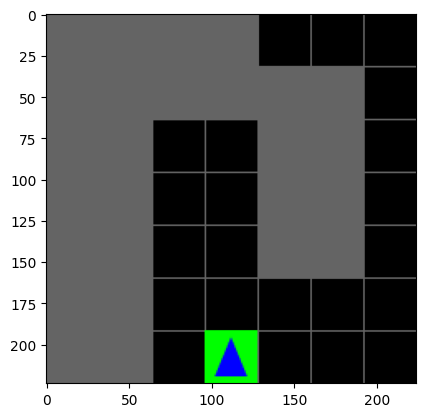

In [2]:
#| hide 
import matplotlib.pyplot as plt
plt.imshow(env.unwrapped.get_goal_state(env.unwrapped.agents[1], agent_view_size=7))
plt.show()

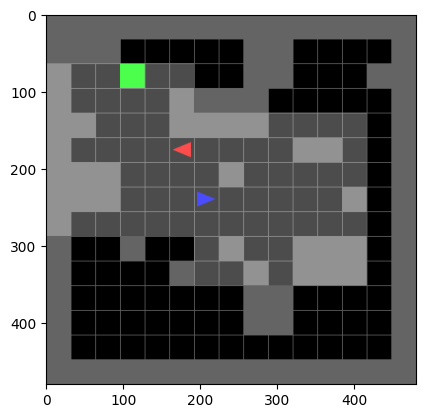

In [3]:
#| hide
plt.imshow(env.unwrapped.render())

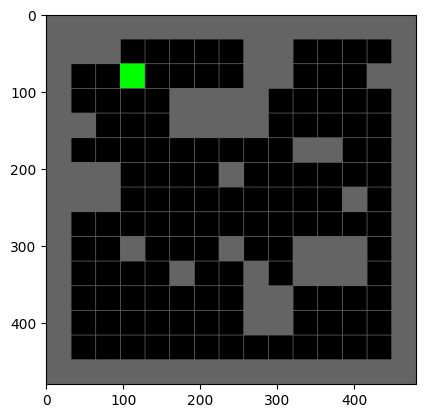

In [4]:
#| hide
plt.imshow(env.unwrapped.get_layout())

In [ ]:
# #| export
# @patch
# def get_goal_state(
#     self: FindGoalEnv,
#     agent: NavigationAgent,
#     agent_view_size: int,
#     tile_size: int = 32,
#     see_through_walls: bool = False,
# ) -> ndarray:
#     """
#     Returns the goal state RGB image for the given agent.
#     The goal state is being one step away from the goal object,
#     facing it.
#     """
#     # Find the goal object position
#     goal_pos = None
#     for x in range(self.grid.width):
#         for y in range(self.grid.height):
#             obj = self.grid.get(x, y)
#             if isinstance(obj, Goal):
#                 goal_pos = np.array([x, y])
#                 break
#         if goal_pos is not None:
#             break

#     if goal_pos is None:
#         raise ValueError("No goal object found in the grid")

#     # Four possible positions around the goal (right, down, left, up)
#     # and the direction the agent must face to look at the goal
#     candidate_positions = [
#         (goal_pos + np.array([1, 0]),  Direction.left),   # agent to the right, facing left
#         (goal_pos + np.array([-1, 0]), Direction.right),  # agent to the left, facing right
#         (goal_pos + np.array([0, 1]),  Direction.up),     # agent below, facing up
#         (goal_pos + np.array([0, -1]), Direction.down),   # agent above, facing down
#     ]

#     # Pick a valid candidate (inside grid, not a wall)
#     goal_agent_pos = None
#     goal_agent_dir = None
#     for pos, dir in candidate_positions:
#         x, y = pos
#         if 0 <= x < self.grid.width and 0 <= y < self.grid.height:
#             cell = self.grid.get(x, y)
#             if cell is None or isinstance(cell, Goal):
#                 goal_agent_pos = pos
#                 goal_agent_dir = dir
#                 break

#     if goal_agent_pos is None:
#         raise ValueError("No valid position adjacent to goal found")

#     # Create a temporary agent state at the goal position
#     goal_agent = NavigationAgent(index=agent.index)
#     goal_agent.state.pos = goal_agent_pos
#     goal_agent.state.dir = goal_agent_dir
#     goal_agent.state.color = agent.state.color.name

#     # Compute obs grid for this goal agent state
#     # We need to temporarily modify agents_states for gen_obs_grid
#     original_pos = agent.state.pos
#     original_dir = agent.state.dir

#     agent.state.pos = goal_agent_pos
#     agent.state.dir = goal_agent_dir

#     # Generate the observation image
#     goal_image = gen_obs_grid_image(
#         self.grid,
#         [goal_agent],
#         self.agent_states,  # uses modified agent state
#         agent_view_size,
#         tile_size=tile_size,
#         see_through_walls=see_through_walls,
#     )[0]

#     # Restore original agent state
#     agent.state.pos = original_pos
#     agent.state.dir = original_dir

#     return goal_image

## Stable World Model trial

In [3]:
#| hide
import multigrid.envs
import stable_worldmodel as swm

world = swm.World('MultiGrid-FindGoal-15x15-v0', num_envs=4, image_shape=(64, 64),
                  **{
                      "render_mode": "rgb_array",
                      "num_obstacles": 6,
                      "width": 15,
                      "height": 15,
                      "agents": 2,
                  })


/home/ahmed/miniconda3/envs/rl/lib/python3.11/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


In [4]:
#| hide
from stable_worldmodel.policy import RandomPolicy

# Create a random policy
policy = RandomPolicy(seed=0)
world.set_policy(policy)

In [7]:
# #| hide
# this will cause errors, since stable-wm does not support dictionary action spaces that we have in multiagent env.
# world.reset(seed=0)

In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()